In [29]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from utils.syncUtilities import plotFramesShiftToSyncrhonizeAllSubjectsOneActivity,getMainJointFromMotAndMainBonesFromCSV, getSamplesToSynchronize, SynchronizeAndCutSignals

## Computes ideal synchronization of IMU and video data records by estimating the RMSE of shifted signals (_.mot_ and _.csv_), and writes this info into `infoToSync.csv`.

In [30]:
import utils.fileProcessing as fileutil 
import utils.plotUtilities as plotutil
import utils.signalProcessing as signalutil

Set dataset root path

In [31]:
fulldatasetpath = '/mnt/b/VIDIMU'

In [32]:
inpath = os.path.join(fulldatasetpath,'dataset', 'dataset_motionagformer','videoandimus')
outpath = os.path.join(fulldatasetpath,'analysis', 'analysis_motionagformer','videoandimusync')
if not os.path.exists(outpath):
    os.makedirs(outpath)

### 1. Synchronization in loop for a list of subjects and activities

In [33]:
lower_activities = ["A01","A02","A03","A04"]
upper_activities = ["A05","A06","A07","A08","A09","A10","A11","A12","A13"]
dataset_activities = lower_activities + upper_activities
activities_legend = ["walk_forward", "walk_backward", "walk_along","sit_to_stand",
"move_right_arm","move_left_arm","drink_right_arm","drink_left_arm", "assemble_both_arms","throw_both_arms",
"reachup_right_arm","reachup_left_arm","tear_both_arms"]

In [34]:
# subjects = ["S40","S41","S42","S44","S46","S47","S48","S49","S50",
#             "S51","S52","S53","S54","S55","S56","S57"]

subjects = ["S40","S41", "S42", "S44"]

In [35]:
RMSE_SAMPLES = 180
FINAL_LENGTH= 180 
MAX_SYNC_OVERLAP = 15

Activity: A01


/home/mario/vidimu-tools/utils/syncUtilities.py:182: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfchanges = pd.concat([dfchanges,entry],ignore_index=True)


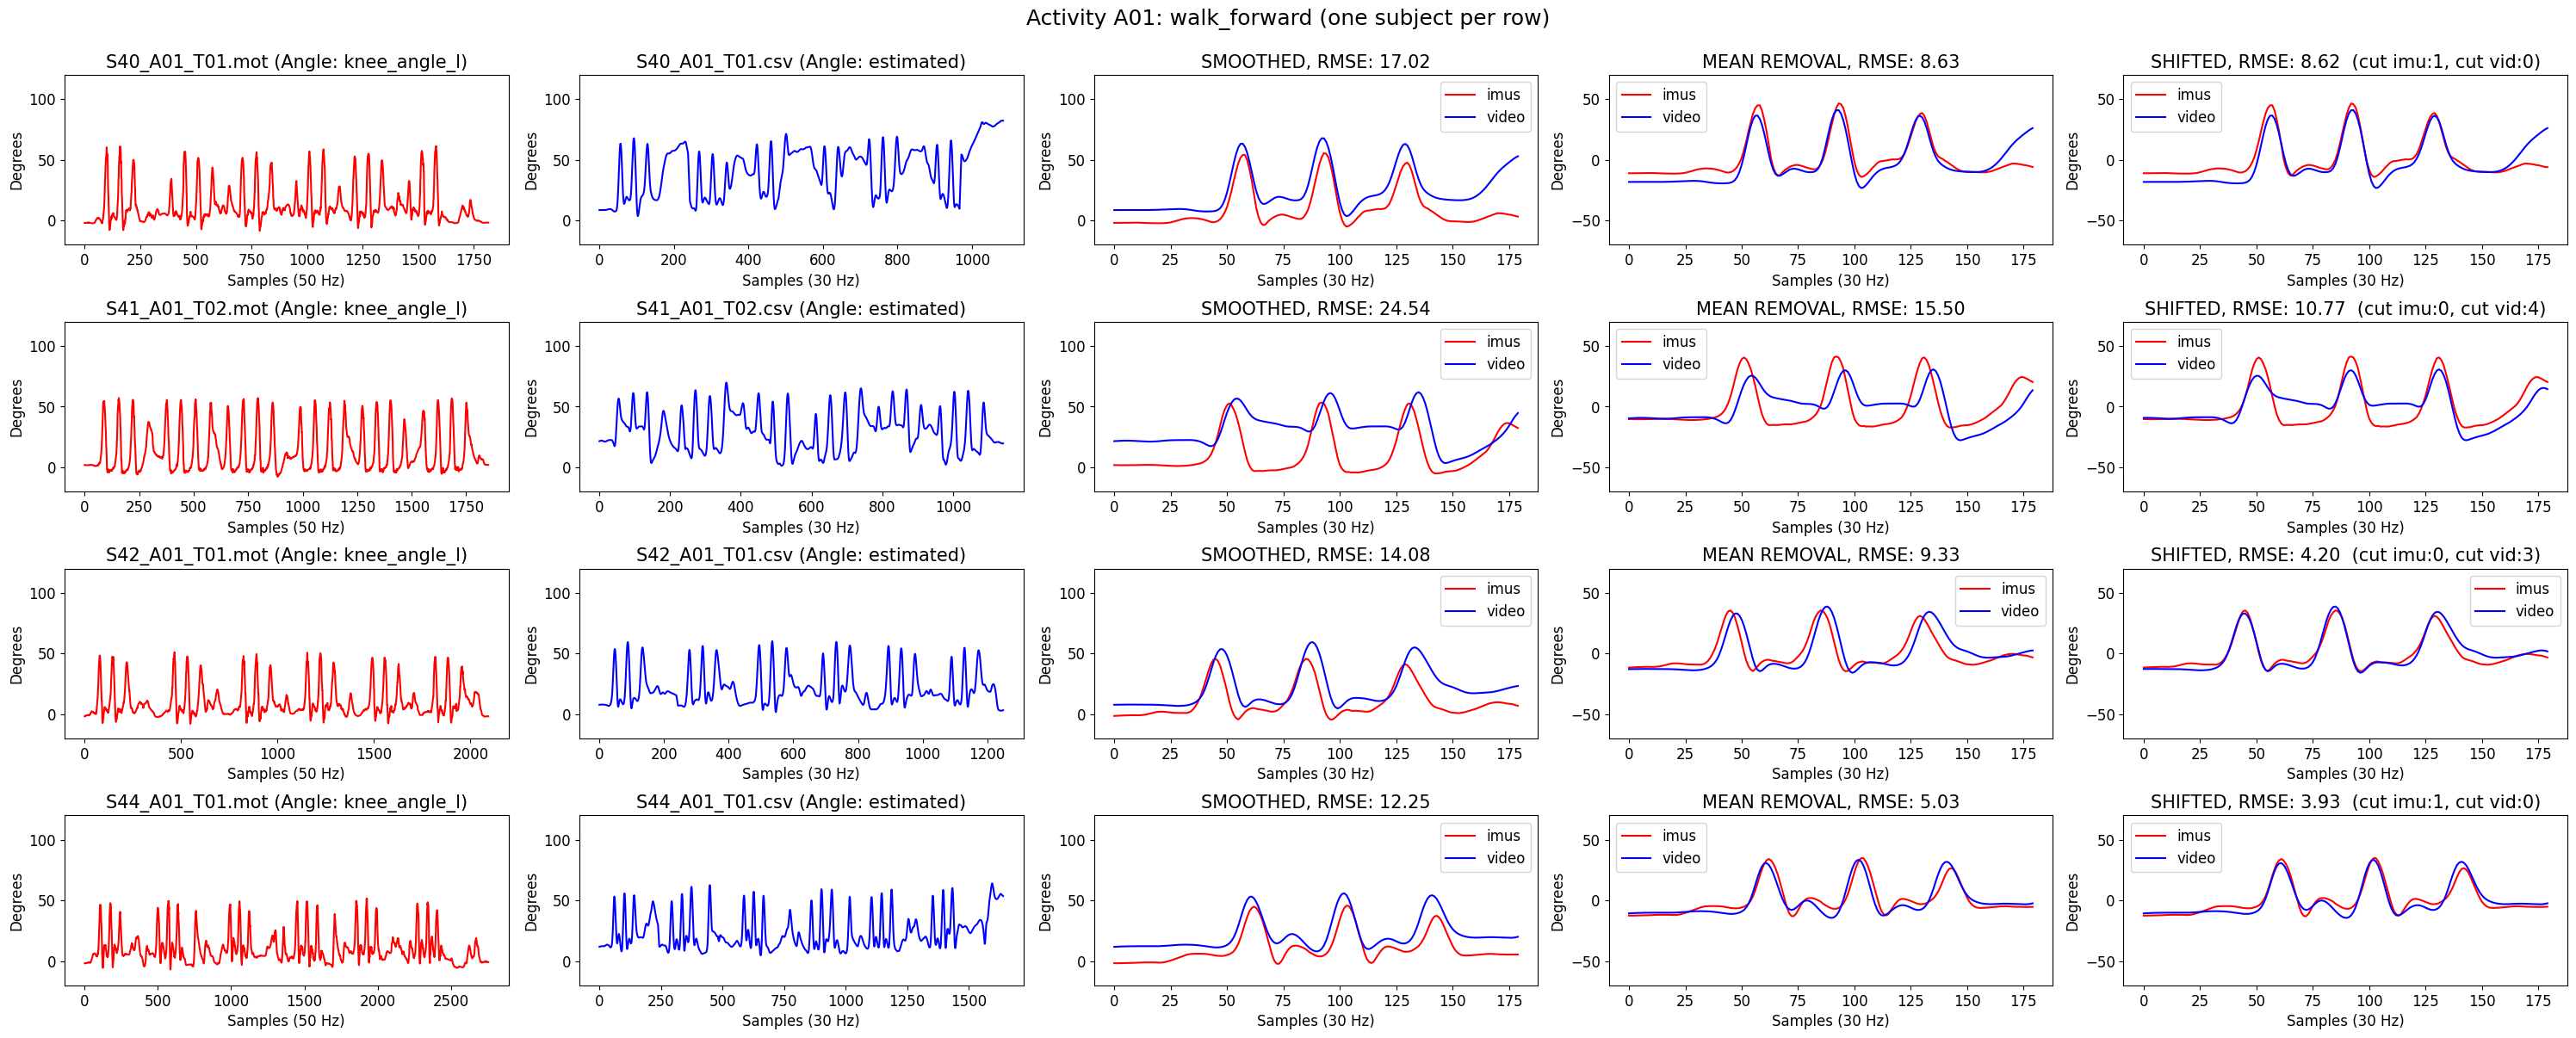

Activity: A02


In [ ]:
rmse_lists = []
index_activity = 0

csvlog='infoToSync.csv'
csvlogfile = os.path.join(outpath,csvlog)
if os.path.exists(csvlogfile):
    os.remove(csvlogfile)
for activity,legend in zip(dataset_activities,activities_legend):
    print("Activity: "+activity)
    rmse_list = plotFramesShiftToSyncrhonizeAllSubjectsOneActivity(csvlog,inpath,outpath,subjects,activity,legend,activity+"_("+legend+")_synchronize",RMSE_SAMPLES=RMSE_SAMPLES,MAX_SYNC_OVERLAP=MAX_SYNC_OVERLAP,FINAL_LENGTH=FINAL_LENGTH)